# Dataset #1: MxMH Dataset EDA

Importing the cleaned dataset and analyzing the first 5 lines.

In [44]:
import pandas as pd
FILE_PATH = "../../data/01-interim/MxMH_Survey_cleaned.csv"
df = pd.read_csv(FILE_PATH)
df.head()

,Timestamp,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,...,Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects,Permissions
0,8/27/2022 19:29:02,18.0,Spotify,3.0,Yes,Yes,Yes,Latin,Yes,Yes,...,Sometimes,Very frequently,Never,Sometimes,3.0,0.0,1.0,0.0,NaN,I understand.
1,8/27/2022 19:57:31,63.0,Pandora,1.5,Yes,No,No,Rock,Yes,No,...,Sometimes,Rarely,Very frequently,Rarely,7.0,2.0,2.0,1.0,NaN,I understand.
2,8/27/2022 21:28:18,18.0,Spotify,4.0,No,No,No,Video game music,No,Yes,...,Never,Rarely,Rarely,Very frequently,7.0,7.0,10.0,2.0,No effect,I understand.
3,8/27/2022 21:40:40,61.0,YouTube Music,2.5,Yes,No,Yes,Jazz,Yes,Yes,...,Sometimes,Never,Never,Never,9.0,7.0,3.0,3.0,Improve,I understand.
4,8/27/2022 21:54:47,18.0,Spotify,4.0,Yes,No,No,R&B,Yes,No,...,Very frequently,Very frequently,Never,Rarely,7.0,2.0,5.0,9.0,Improve,I understand.


Describing the dataset and its stats for numerical columns

In [6]:
df.describe()

,Age,Hours per day,BPM,Anxiety,Depression,Insomnia,OCD
count,735.000000,735.000000,6.290000e+02,735.000000,735.000000,735.000000,735.000000
mean,25.206803,3.573537,1.589948e+06,5.833333,4.798639,3.740816,2.631293
std,12.054970,3.030187,3.987261e+07,2.792515,3.030206,3.090126,2.839383
min,10.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,18.000000,2.000000,1.000000e+02,4.000000,2.000000,1.000000,0.000000
50%,21.000000,3.000000,1.200000e+02,6.000000,5.000000,3.000000,2.000000
75%,28.000000,5.000000,1.440000e+02,8.000000,7.000000,6.000000,4.500000
max,89.000000,24.000000,1.000000e+09,10.000000,10.000000,10.000000,10.000000


Displaying info for the dataset and their non-null counts and data types

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 735 entries, 0 to 734
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Timestamp                     735 non-null    object 
 1   Age                           735 non-null    float64
 2   Primary streaming service     735 non-null    object 
 3   Hours per day                 735 non-null    float64
 4   While working                 735 non-null    object 
 5   Instrumentalist               735 non-null    object 
 6   Composer                      735 non-null    object 
 7   Fav genre                     735 non-null    object 
 8   Exploratory                   735 non-null    object 
 9   Foreign languages             735 non-null    object 
 10  BPM                           629 non-null    float64
 11  Frequency [Classical]         735 non-null    object 
 12  Frequency [Country]           735 non-null    object 
 13  Frequ

Verifying number of null values is 0 except the BPM column

In [8]:
print("NaNs per colum:\n", df.isnull().sum())
print("\nTotal NaNs in dataset:", df.isnull().sum().sum())

NaNs per colum:
 Timestamp                         0
Age                               0
Primary streaming service         0
Hours per day                     0
While working                     0
Instrumentalist                   0
Composer                          0
Fav genre                         0
Exploratory                       0
Foreign languages                 0
BPM                             106
Frequency [Classical]             0
Frequency [Country]               0
Frequency [EDM]                   0
Frequency [Folk]                  0
Frequency [Gospel]                0
Frequency [Hip hop]               0
Frequency [Jazz]                  0
Frequency [K pop]                 0
Frequency [Latin]                 0
Frequency [Lofi]                  0
Frequency [Metal]                 0
Frequency [Pop]                   0
Frequency [R&B]                   0
Frequency [Rap]                   0
Frequency [Rock]                  0
Frequency [Video game music]      0
Anxiety    

Analyzing the distribution of BPMs in the dataset through box plots

c:\Users\evanc\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


Text(0.5, 1.0, 'Box Plot of BPMs')

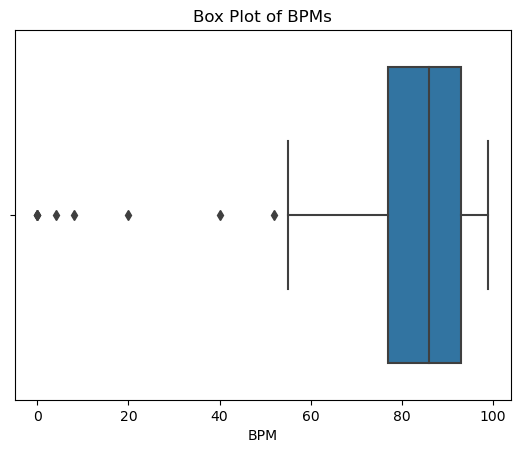

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Notice that there's an outlier in BPM all the way to the 9th order of magnitude, we will prune that through thresholding.
clean_df = df[df['BPM'] < 1e2]
bpm_box = sns.boxplot(data=clean_df, x='BPM')
bpm_box.set_title('Box Plot of BPMs')

In [24]:
ENCODED_FILE_PATH = "../../data/02-processed/MxMH_Survey_encoded.csv"
encoded_df = pd.read_csv(ENCODED_FILE_PATH)
encoded_df.head()

,Age,Hours per day,While working,Instrumentalist,Composer,Exploratory,BPM,Frequency [Classical],Frequency [Country],Frequency [EDM],...,Fav genre_Lofi,Fav genre_Metal,Fav genre_Pop,Fav genre_R&B,Fav genre_Rap,Fav genre_Rock,Fav genre_Video game music,Music effects_No effect,Music effects_Worsen,Music effects_nan
0,18.0,3.0,1,1,1,1,156.0,1,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,63.0,1.5,1,0,0,1,119.0,2,0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,18.0,4.0,0,0,0,0,132.0,0,0,3,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
3,61.0,2.5,1,0,1,1,84.0,2,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,18.0,4.0,1,0,0,1,107.0,0,0,1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
# Imports and data load
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import chi2_contingency, spearmanr

sns.set(style="whitegrid")

# Ensure frequency columns exist and are numeric
freq_cols = [c for c in encoded_df.columns if c.startswith("Frequency [")]
for c in freq_cols:
    encoded_df[c] = pd.to_numeric(encoded_df[c], errors='coerce')

# Binary mental-health indicators (present if score > 0)
mh_cols = ["Anxiety", "Depression", "Insomnia", "OCD"]
for c in mh_cols:
    if c in encoded_df.columns:
        encoded_df[c] = pd.to_numeric(encoded_df[c], errors='coerce')
        encoded_df[c + "_present"] = (encoded_df[c] > 0).astype(int)

# Create output figure dir
fig_dir = Path('results/figures')
fig_dir.mkdir(parents=True, exist_ok=True)

print('Frequency cols:', freq_cols)
print('Mental-health cols:', [c for c in mh_cols if c in df.columns])

Frequency cols: ['Frequency [Classical]', 'Frequency [Country]', 'Frequency [EDM]', 'Frequency [Folk]', 'Frequency [Gospel]', 'Frequency [Hip hop]', 'Frequency [Jazz]', 'Frequency [K pop]', 'Frequency [Latin]', 'Frequency [Lofi]', 'Frequency [Metal]', 'Frequency [Pop]', 'Frequency [R&B]', 'Frequency [Rap]', 'Frequency [Rock]', 'Frequency [Video game music]']
Mental-health cols: ['Anxiety', 'Depression', 'Insomnia', 'OCD']


c:\Users\evanc\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\evanc\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\evanc\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\evanc\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_cat

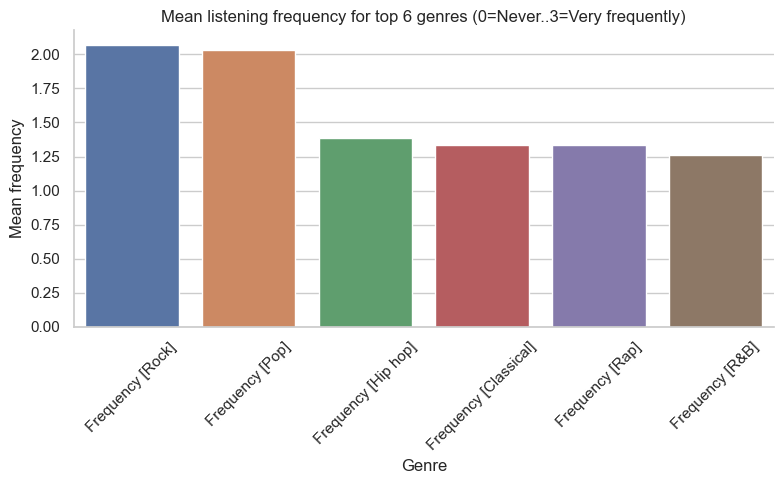

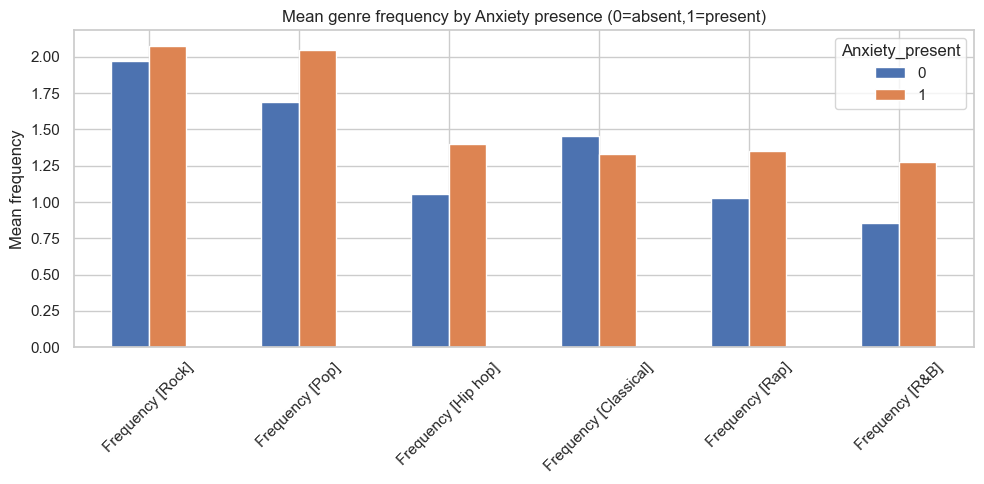

In [22]:
# Grouped bar chart: mean frequency for top genres by mental-health presence
# Select top 6 genres by mean frequency
top_genres = sorted(freq_cols, key=lambda c: df[c].mean(skipna=True), reverse=True)[:6]

g = sns.catplot(
    data=pd.melt(df, id_vars=[c + "_present" for c in mh_cols if c in df.columns], value_vars=top_genres, var_name='genre', value_name='freq'),
    x='genre', y='freq', hue='variable' if False else None, kind='bar', errorbar=None, height=5, aspect=1.6
)
plt.title('Mean listening frequency for top 6 genres (0=Never..3=Very frequently)')
plt.ylabel('Mean frequency')
plt.xlabel('Genre')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(fig_dir / 'mean_freq_top_genres.png')
plt.show()

# Better: compare mean frequency for each genre split by Anxiety_present
comp = df.groupby('Anxiety_present')[top_genres].mean().T
comp.plot(kind='bar', figsize=(10,5))
plt.title('Mean genre frequency by Anxiety presence (0=absent,1=present)')
plt.ylabel('Mean frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(fig_dir / 'mean_genres_by_anxiety.png')
plt.show()

Heatmap of Spearman correlations between genre frequencies and mental-health scores

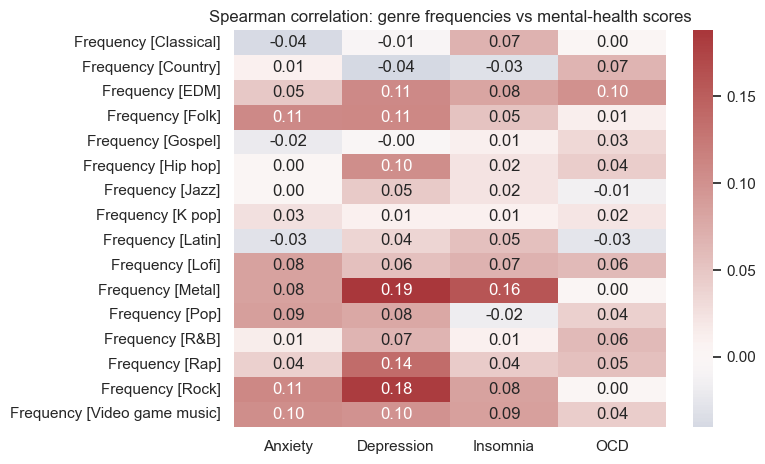

In [23]:
mh_numeric = [c for c in mh_cols if c in df.columns]
if len(freq_cols) and len(mh_numeric):
    corr_mat = df[freq_cols + mh_numeric].corr(method='spearman').loc[freq_cols, mh_numeric]
    plt.figure(figsize=(8, max(4, 0.3*len(freq_cols))))
    sns.heatmap(corr_mat, center=0, cmap='vlag', annot=True, fmt='.2f')
    plt.title('Spearman correlation: genre frequencies vs mental-health scores')
    plt.tight_layout()
    plt.savefig(fig_dir / 'corr_genres_mh.png')
    plt.show()
else:
    print('Not enough columns for correlation heatmap.')

In [17]:
# Chi-square tests between binarized genre frequency (frequent vs infrequent) and MH presence
from math import sqrt
results = []
for g in freq_cols:
    # binarize: frequent if >=2
    df['g_freq_high'] = (df[g] >= 2).astype(int)
    for m in mh_cols:
        m_present = m + '_present'
        if m_present in df.columns:
            table = pd.crosstab(df['g_freq_high'], df[m_present])
            if table.shape == (2,2):
                chi2, p, dof, ex = chi2_contingency(table)
                n = table.values.sum()
                phi2 = chi2 / n
                # Cramer's V for 2x2
                cramers_v = sqrt(phi2 / min(table.shape)-1) if n>0 else np.nan
                results.append({'genre': g, 'mh': m, 'chi2': chi2, 'p': p, 'cramers_v': cramers_v})

res_df = pd.DataFrame(results).sort_values('p')
res_df.head(20)

res_df.to_csv(fig_dir / 'chi2_results.csv', index=False)
print('Saved chi-square results to', fig_dir / 'chi2_results.csv')

ValueError: math domain error

c:\Users\evanc\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\evanc\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


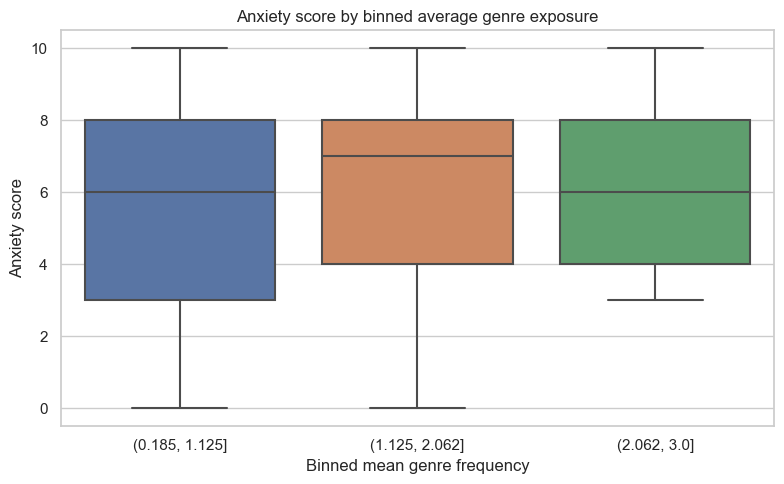

In [ ]:
# Boxplot: aggregate genre exposure (mean frequency across genres) vs Anxiety score
df['genre_mean'] = df[freq_cols].mean(axis=1)
plt.figure(figsize=(8,5))
sns.boxplot(x=pd.cut(df['genre_mean'], bins=3), y=df['Anxiety'])
plt.title('Anxiety score by binned average genre exposure')
plt.xlabel('Binned mean genre frequency')
plt.ylabel('Anxiety score')
plt.tight_layout()
plt.savefig(fig_dir / 'anxiety_by_genre_mean_boxplot.png')
plt.show()

Favorite Genre vs Mental Health Analysis and Heatmap

Top favorite genres:
Fav genre
Rock                188
Pop                 114
Metal                88
Classical            53
Video game music     44
EDM                  37
R&B                  35
Hip hop              34
Folk                 30
K pop                26
Name: count, dtype: int64


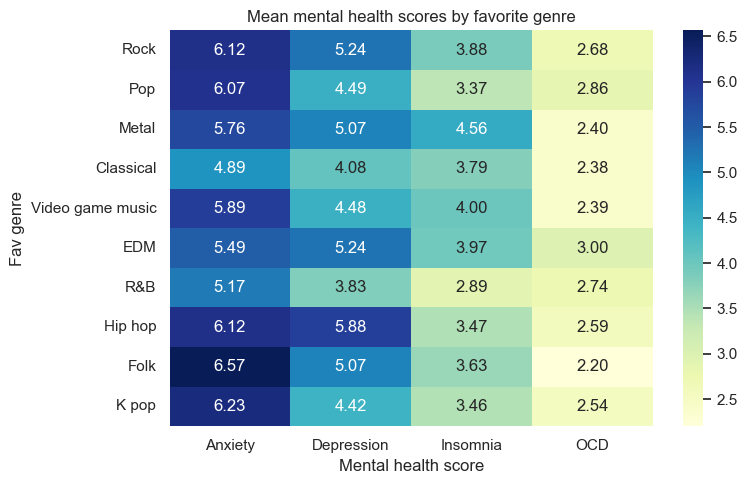

In [45]:
# Favorite genre vs mental health analysis
from math import sqrt
from pathlib import Path

fav_df = pd.read_csv(FILE_PATH)
mh_cols_local = [c for c in ['Anxiety', 'Depression', 'Insomnia', 'OCD'] if c in fav_df.columns]
for c in mh_cols_local:
    fav_df[c] = pd.to_numeric(fav_df[c], errors='coerce')
    fav_df[c + '_present'] = (fav_df[c] > 0).astype(int)

# Focus on the most common favorite genres for readable plots
genre_col = 'Fav genre'
fav_counts = fav_df[genre_col].value_counts()
top_fav_genres = fav_counts.head(10).index.tolist()
df_fav = fav_df[fav_df[genre_col].isin(top_fav_genres)].copy()

print('Top favorite genres:')
print(fav_counts.head(10))

# Heatmap of mean mental health scores by favorite genre
heatmap_data = df_fav.groupby(genre_col)[mh_cols_local].mean().reindex(top_fav_genres)
plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Mean mental health scores by favorite genre')
plt.xlabel('Mental health score')
plt.ylabel('Fav genre')
plt.tight_layout()
plt.savefig(fig_dir / 'fav_genre_mh_heatmap.png')
plt.show()



In [ ]:
# Find correlation between Hours per day and Mental health


In [ ]:
# Prevalence of each mental-health condition by favorite genre
prev_rows = []
for mh in mh_cols_local:
    present_col = mh + '_present'
    prev = (
        df_fav.groupby(genre_col)[present_col]
        .mean()
        .reindex(top_fav_genres)
        .reset_index(name='prevalence')
    )
    prev['condition'] = mh
    prev_rows.append(prev)
prev_df = pd.concat(prev_rows, ignore_index=True)

plt.figure(figsize=(11, 6))
sns.barplot(data=prev_df, x=genre_col, y='prevalence', hue='condition')
plt.title('Prevalence of mental-health conditions by favorite genre')
plt.ylabel('Share with condition present')
plt.xlabel('Fav genre')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(fig_dir / 'fav_genre_mh_prevalence.png')
plt.show()

### Chi-square test of association between favorite genre and each mental-health indicator

Based on the results of the p-values for each association in the chi-square test below, we can see that depression is the only significant finding with a p-value of 0.031, below the standard α = 0.05 threshold for statistical significance. This means that the distribution of favorite genres differs meaningfully between people who report depression and those who don't.

However, because its Cramer's V value (for effect size) is 0.19, it can be inferred that although the association between Depression and favorite genre is statistically significant, the strength of the relationship is modest in which genre explains a small portion of variance in depression presence.

Ultimately, the chi-square test on these features tell us that there is an association between Depression and favorite genre, but it does not prove that there is any causality between the features. It is also worth noting that with four simultaneous tests at α = 0.05, there is approximately a 19% chance of at least one false positive occurring by chance alone, meaning the Depression result should be interpreted with some caution.

In [ ]:
chi_rows = []
for mh in mh_cols_local:
    present_col = mh + '_present'
    table = pd.crosstab(fav_df[genre_col], fav_df[present_col])
    chi2, p, dof, expected = chi2_contingency(table)
    n_obs = table.to_numpy().sum()
    cramer_v = sqrt(chi2 / (n_obs * min(table.shape[0] - 1, table.shape[1] - 1)))
    chi_rows.append({
        'condition': mh,
        'chi2': chi2,
        'p_value': p,
        'cramers_v': cramer_v,
        'dof': dof,
    })

chi_df = pd.DataFrame(chi_rows).sort_values('p_value')
print('\nChi-square association between favorite genre and mental-health presence:')
print(chi_df.to_string(index=False))


Chi-square association between favorite genre and mental-health presence:
 condition      chi2  p_value  cramers_v  dof
Depression 26.786716 0.030523   0.190904   15
   Anxiety 24.681034 0.054395   0.183247   15
  Insomnia 19.726530 0.182676   0.163826   15
       OCD 12.339155 0.653197   0.129568   15


In [57]:
encoded_df = pd.read_csv(ENCODED_FILE_PATH)
fav_genres = [c for c in encoded_df.columns if c.startswith('Fav genre')]
mh_conditions = ['Anxiety', 'Depression', 'Insomnia', 'OCD']
fav_genres_df = encoded_df[fav_genres + mh_conditions]
fav_genres_df.head()

,Fav genre_Country,Fav genre_EDM,Fav genre_Folk,Fav genre_Gospel,Fav genre_Hip hop,Fav genre_Jazz,Fav genre_K pop,Fav genre_Latin,Fav genre_Lofi,Fav genre_Metal,Fav genre_Pop,Fav genre_R&B,Fav genre_Rap,Fav genre_Rock,Fav genre_Video game music,Anxiety,Depression,Insomnia,OCD
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,7.0,2.0,2.0,1.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,7.0,7.0,10.0,2.0
3,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0,7.0,3.0,3.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,7.0,2.0,5.0,9.0


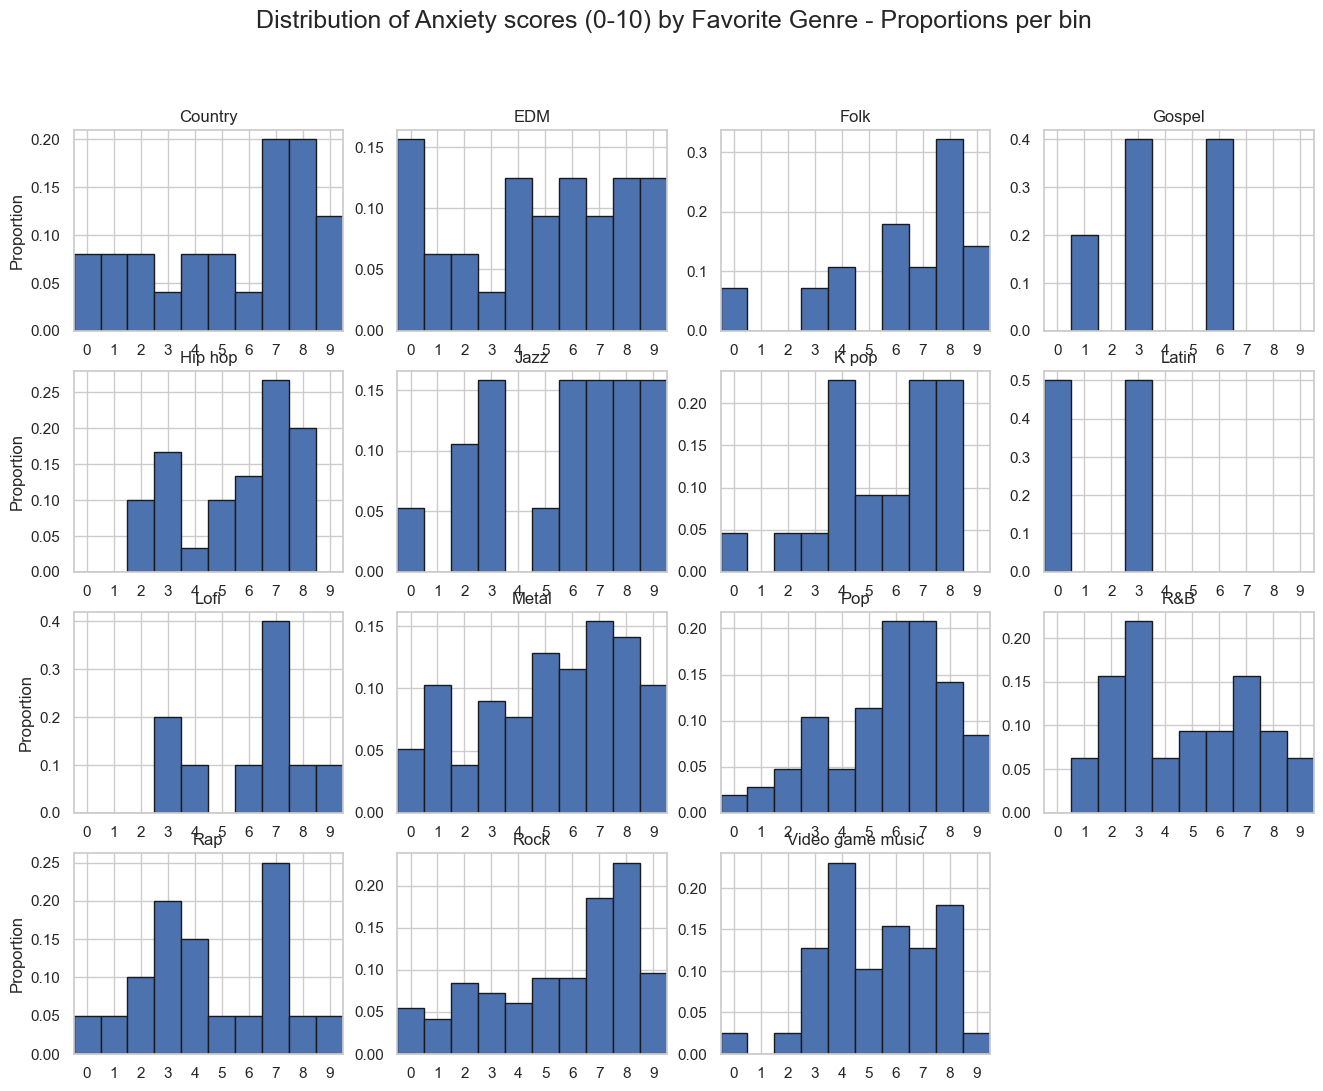

In [61]:
import math

CONDITION = "Anxiety"

encoded_df = pd.read_csv(ENCODED_FILE_PATH)
fav_genres = [c for c in encoded_df.columns if c.startswith('Fav genre')]
mh_conditions = ['Anxiety', 'Depression', 'Insomnia', 'OCD']
fav_genres_df = encoded_df[fav_genres + mh_conditions]

bin_edges = np.arange(-0.5, 10.5, 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
ncols = 4
nrows = math.ceil(len(fav_genres) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*3), squeeze=False)
axes = axes.flatten()

for i, gen_col in enumerate(fav_genres):
    ax = axes[i]
    scores = pd.to_numeric(fav_genres_df.loc[fav_genres_df[gen_col] == 1, CONDITION], errors="coerce").dropna()
    counts, _ = np.histogram(scores, bins=bin_edges)
    vals = counts / counts.sum() if counts.sum() > 0 else counts
    ax.bar(bin_centers, vals, width=1.0, align='center', color="C0", edgecolor="k")
    ax.set_title(gen_col.replace("Fav genre_", ""))
    ax.set_xticks(bin_centers)
    ax.set_xticklabels(range(0, len(counts)))
    ax.set_xlim(bin_edges[0], bin_edges[-1])
    if i % ncols == 0:
        ax.set_ylabel("Proportion")

for j in range(len(fav_genres), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Distribution of Anxiety scores (0-10) by Favorite Genre - Proportions per bin", fontsize=18)
plt.savefig(f"results/figures/{CONDITION}_by_fav_genre_binned.png", dpi=150)
plt.show()

PCA Dimensionality Reduction

PCA loadings (feature weights by component):
                                PC1    PC2    PC3    PC4    PC5    PC6    PC7  \
Frequency [Classical]         0.045 -0.096  0.435  0.385 -0.236 -0.158  0.021   
Frequency [Country]           0.065 -0.315  0.209 -0.348  0.430  0.196 -0.088   
Frequency [EDM]               0.206 -0.077 -0.322  0.226  0.283  0.279  0.353   
Frequency [Folk]              0.085 -0.480  0.174 -0.107  0.153 -0.020 -0.272   
Frequency [Gospel]            0.167 -0.114  0.416 -0.072  0.141  0.470  0.068   
Frequency [Hip hop]           0.422  0.076 -0.176 -0.208 -0.288  0.200 -0.109   
Frequency [Jazz]              0.243 -0.175  0.307  0.188 -0.411 -0.077  0.064   
Frequency [K pop]             0.286  0.207 -0.024  0.167  0.355 -0.167  0.382   
Frequency [Latin]             0.280 -0.036  0.267 -0.001  0.062 -0.143  0.458   
Frequency [Lofi]              0.304 -0.066 -0.084  0.369  0.069  0.042 -0.437   
Frequency [Metal]            -0.067 -0.473 -0.292 -0.014 -0.193 

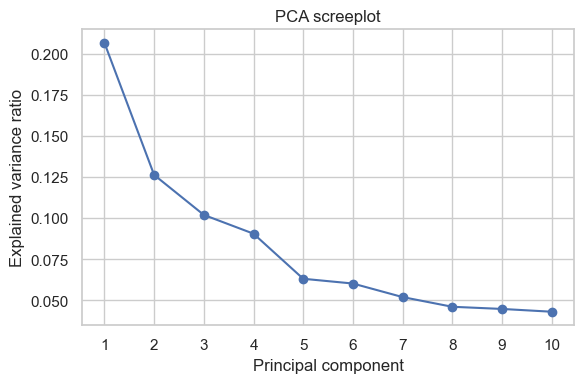

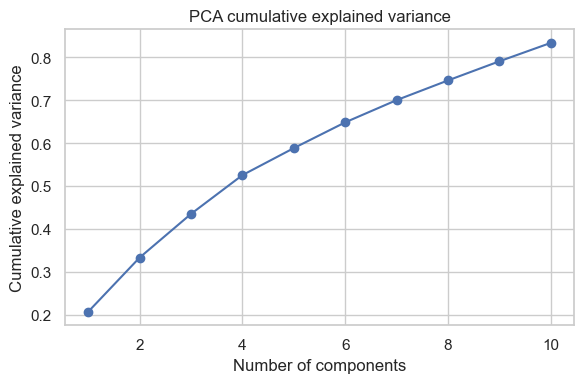

In [38]:
# Dimensionality reduction: PCA
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df_dr = pd.read_csv(ENCODED_FILE_PATH)

# Frequency columns
freq_cols_dr = [c for c in df_dr.columns if c.startswith('Frequency [')]

X = df_dr[freq_cols_dr].fillna(0).astype(float)
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

# PCA for variance overview and dimensionality reduction
pca = PCA(n_components=min(10, Xs.shape[1]))
X_pca = pca.fit_transform(Xs)
explained_var = pca.explained_variance_ratio_
component_numbers = np.arange(1, len(explained_var) + 1)

# Print feature loadings and readable linear combinations for each component
loadings = pd.DataFrame(
    pca.components_.T,
    index=freq_cols_dr,
    columns=[f'PC{i}' for i in component_numbers],
)
print('PCA loadings (feature weights by component):')
print(loadings.round(3))

print('\nTop contributing features per principal component:')
for pc_idx, pc_name in enumerate(loadings.columns, start=1):
    top_terms = loadings[pc_name].abs().sort_values(ascending=False).head(5).index
    terms = [f"{loadings.loc[feature, pc_name]:+.3f}*{feature}" for feature in top_terms]
    print(f"{pc_name} = " + ' '.join(terms))

# Screeplot: explained variance by component
plt.figure(figsize=(6,4))
plt.plot(component_numbers, explained_var, marker='o')
plt.xlabel('Principal component')
plt.ylabel('Explained variance ratio')
plt.title('PCA screeplot')
plt.xticks(component_numbers)
plt.grid(True)
plt.tight_layout()
plt.savefig(fig_dir / 'pca_screeplot.png')
plt.show()

# Cumulative variance plot
plt.figure(figsize=(6,4))
plt.plot(component_numbers, np.cumsum(explained_var), marker='o')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA cumulative explained variance')
plt.grid(True)
plt.tight_layout()
plt.savefig(fig_dir / 'pca_explained_variance.png')
plt.show()


c:\Users\evanc\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\evanc\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


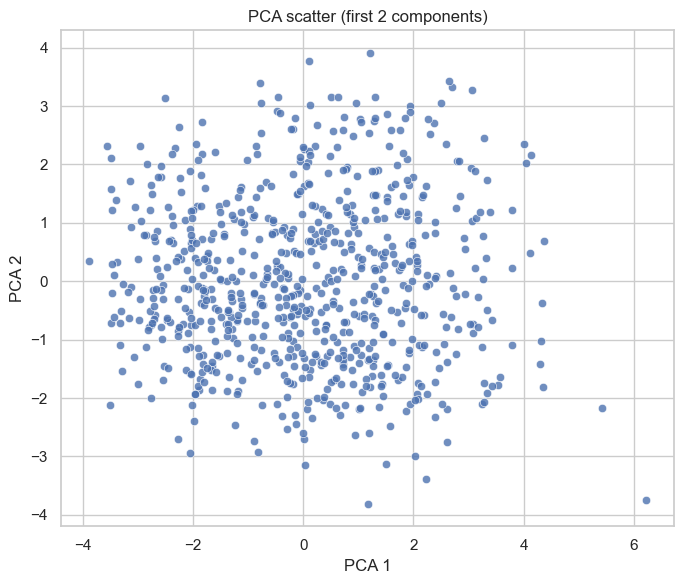

In [28]:
# Scatter first two PCA components colored by Anxiety presence if available
color_col = None
if 'Anxiety_present' in df_dr.columns:
    color_col = 'Anxiety_present'
elif 'Depression_present' in df_dr.columns:
    color_col = 'Depression_present'

plt.figure(figsize=(7,6))
if color_col is not None:
    sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df_dr[color_col], palette='tab10', alpha=0.8)
    plt.legend(title=color_col)
else:
    sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], alpha=0.8)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('PCA scatter (first 2 components)')
plt.tight_layout()
plt.savefig(fig_dir / 'pca_scatter.png')
plt.show()

c:\Users\evanc\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\evanc\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


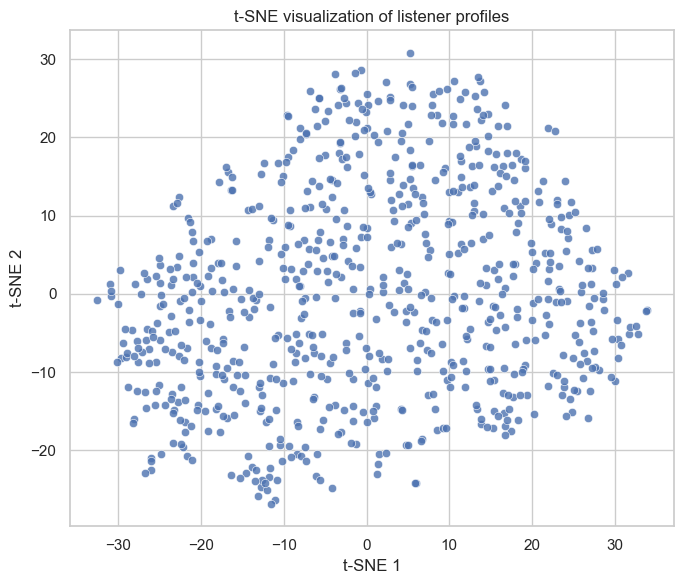

In [29]:
# t-SNE on PCA-reduced data for visualization (use first 10 PCA comps if available)
n_pcs = min(10, X_pca.shape[1])
X_for_tsne = X_pca[:, :n_pcs]

tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca')
X_tsne = tsne.fit_transform(X_for_tsne)

plt.figure(figsize=(7,6))
if color_col is not None:
    sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=df_dr[color_col], palette='tab10', alpha=0.8)
    plt.legend(title=color_col)
else:
    sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], alpha=0.8)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE visualization of listener profiles')
plt.tight_layout()
plt.savefig(fig_dir / 'tsne_scatter.png')
plt.show()